In [1]:
import pandas as pd

In [6]:
train_df = pd.read_csv("train.csv")

In [7]:
train_df

,id,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,0,15779985.0,Nwankwo,678.0,France,Male,29.0,4.0,0.00,3.0,1.0,0.0,180626.36,0.0
1,1,15650086.0,Ch'in,687.0,France,Female,34.0,1.0,0.00,2.0,0.0,1.0,63736.17,0.0
2,2,15733602.0,Thompson,682.0,France,Female,52.0,6.0,0.00,3.0,0.0,0.0,179655.87,1.0
3,3,15645794.0,Macleod,753.0,Germany,Male,44.0,6.0,83347.25,2.0,1.0,0.0,161407.48,0.0
4,4,15633840.0,Hsia,544.0,Germany,Female,55.0,0.0,107747.57,1.0,1.0,0.0,176580.86,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14995,14995,15807989.0,Ch'iu,585.0,France,Male,33.0,3.0,0.00,1.0,1.0,0.0,54191.38,0.0
14996,14996,15731781.0,Ch'ang,678.0,France,Male,34.0,6.0,0.00,2.0,1.0,1.0,53437.10,0.0
14997,14997,15667093.0,Goliwe,678.0,France,Female,54.0,4.0,0.00,1.0,1.0,0.0,147720.29,1.0
14998,14998,15732644.0,Fanucci,705.0,Spain,Female,40.0,7.0,0.00,2.0,1.0,0.0,149550.95,0.0


In [8]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   id               15000 non-null  int64  
 1   CustomerId       15000 non-null  float64
 2   Surname          15000 non-null  object 
 3   CreditScore      15000 non-null  float64
 4   Geography        15000 non-null  object 
 5   Gender           15000 non-null  object 
 6   Age              15000 non-null  float64
 7   Tenure           15000 non-null  float64
 8   Balance          15000 non-null  float64
 9   NumOfProducts    15000 non-null  float64
 10  HasCrCard        15000 non-null  float64
 11  IsActiveMember   15000 non-null  float64
 12  EstimatedSalary  15000 non-null  float64
 13  Exited           15000 non-null  float64
dtypes: float64(10), int64(1), object(3)
memory usage: 1.6+ MB


In [9]:
from sklearn.model_selection import train_test_split

train_data, val_data = train_test_split(
    train_df,
    test_size=0.25,
    random_state=42
)

In [13]:
test_data = pd.read_csv("test.csv")

In [14]:
print('train_data.shape :', train_data.shape)
print('val_data.shape :', val_data.shape)
print('test_data.shape :', test_data.shape)

train_data.shape : (11250, 14)
val_data.shape : (3750, 14)
test_data.shape : (10000, 13)


In [20]:
input_cols = [
    'CreditScore',
    'Geography',
    'Gender',
    'Age',
    'Tenure',
    'Balance',
    'NumOfProducts',
    'HasCrCard',
    'IsActiveMember',
    'EstimatedSalary'
]

target_col = 'Exited'

In [21]:
print(input_cols)

['CreditScore', 'Geography', 'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary']


In [22]:
target_col

'Exited'

In [23]:
train_inputs = train_data[input_cols].copy()
train_targets = train_data[target_col].copy()

In [24]:
val_inputs = val_data[input_cols].copy()
val_targets = val_data[target_col].copy()

In [26]:
test_inputs = test_data[input_cols].copy()

In [27]:
import numpy as np

In [28]:
numeric_cols = train_inputs.select_dtypes(include=np.number).columns.tolist()
categorical_cols = train_inputs.select_dtypes('object').columns.tolist()

In [29]:
numeric_cols, categorical_cols

(['CreditScore',
  'Age',
  'Tenure',
  'Balance',
  'NumOfProducts',
  'HasCrCard',
  'IsActiveMember',
  'EstimatedSalary'],
 ['Geography', 'Gender'])

In [31]:
train_inputs[numeric_cols].describe().round(2)

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary
count,11250.00,11250.00,11250.00,11250.00,11250.00,11250.00,11250.00,11250.00
mean,659.70,37.72,5.01,42289.10,1.60,0.79,0.49,117881.64
std,72.47,8.22,2.78,59506.53,0.54,0.41,0.50,45741.40
min,431.00,18.00,0.00,0.00,1.00,0.00,0.00,11.58
25%,604.00,32.00,3.00,0.00,1.00,1.00,0.00,83085.03
50%,663.00,37.00,5.00,0.00,2.00,1.00,0.00,123587.83
75%,709.00,42.00,7.00,108902.95,2.00,1.00,1.00,157097.09
max,850.00,74.00,10.00,209767.31,4.00,1.00,1.00,199992.48


In [32]:
train_inputs[categorical_cols].nunique()

Geography    3
Gender       2
dtype: int64

In [33]:
from sklearn.impute import SimpleImputer

In [35]:
imputer = SimpleImputer(strategy = 'mean')

In [36]:
train_df.shape

(15000, 14)

In [37]:
train_df[numeric_cols].isna().sum()

CreditScore        0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
dtype: int64

In [38]:
train_df[numeric_cols].describe()

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary
count,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000
mean,658.944133,37.739600,5.025267,42729.791988,1.590933,0.788800,0.489667,117784.666193
std,72.255926,8.218363,2.776678,59727.309419,0.532306,0.408174,0.499910,45734.445888
min,431.000000,18.000000,0.000000,0.000000,1.000000,0.000000,0.000000,11.580000
25%,603.000000,32.000000,3.000000,0.000000,1.000000,1.000000,0.000000,83058.140000
50%,662.000000,37.000000,5.000000,0.000000,2.000000,1.000000,0.000000,123584.870000
75%,708.000000,42.000000,7.000000,109531.017500,2.000000,1.000000,1.000000,156884.705000
max,850.000000,74.000000,10.000000,209767.310000,4.000000,1.000000,1.000000,199992.480000


In [39]:
from sklearn.preprocessing import MinMaxScaler

In [40]:
scaler = MinMaxScaler()

In [41]:
scaler.fit(train_inputs[numeric_cols])

,feature_range,"(0, ...)"
,copy,True
,clip,False


In [42]:
train_inputs[numeric_cols] = scaler.transform(train_inputs[numeric_cols])
val_inputs[numeric_cols] = scaler.transform(val_inputs[numeric_cols])
test_inputs[numeric_cols] = scaler.transform(test_inputs[numeric_cols])

In [43]:
train_inputs[numeric_cols].describe().round(2)

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary
count,11250.00,11250.00,11250.00,11250.00,11250.00,11250.00,11250.00,11250.00
mean,0.55,0.35,0.50,0.20,0.20,0.79,0.49,0.59
std,0.17,0.15,0.28,0.28,0.18,0.41,0.50,0.23
min,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,0.41,0.25,0.30,0.00,0.00,1.00,0.00,0.42
50%,0.55,0.34,0.50,0.00,0.33,1.00,0.00,0.62
75%,0.66,0.43,0.70,0.52,0.33,1.00,1.00,0.79
max,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00


In [44]:
train_df[categorical_cols].nunique()

Geography    3
Gender       2
dtype: int64

In [45]:
from sklearn.preprocessing import OneHotEncoder

In [46]:
encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')

In [47]:
encoder.fit(train_inputs[categorical_cols])

,categories,'auto'
,drop,None
,sparse_output,False
,dtype,<class 'numpy.float64'>
,handle_unknown,'ignore'
,min_frequency,None
,max_categories,None
,feature_name_combiner,'concat'


In [48]:
encoder.categories_

[array(['France', 'Germany', 'Spain'], dtype=object),
 array(['Female', 'Male'], dtype=object)]

In [49]:
encoded_cols = list(encoder.get_feature_names_out(categorical_cols))
print(encoded_cols)

['Geography_France', 'Geography_Germany', 'Geography_Spain', 'Gender_Female', 'Gender_Male']


In [50]:
encoder.transform(train_inputs[categorical_cols])[:10]

array([[0., 1., 0., 1., 0.],
       [1., 0., 0., 0., 1.],
       [1., 0., 0., 1., 0.],
       [0., 0., 1., 0., 1.],
       [0., 0., 1., 0., 1.],
       [0., 0., 1., 0., 1.],
       [1., 0., 0., 0., 1.],
       [1., 0., 0., 0., 1.],
       [0., 0., 1., 0., 1.],
       [0., 1., 0., 1., 0.]])

In [51]:
train_inputs[encoded_cols] = encoder.transform(train_inputs[categorical_cols])
val_inputs[encoded_cols] = encoder.transform(val_inputs[categorical_cols])
test_inputs[encoded_cols] = encoder.transform(test_inputs[categorical_cols])

In [52]:
pd.set_option('display.max_columns', None)

In [53]:
test_inputs

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Geography_France,Geography_Germany,Geography_Spain,Gender_Female,Gender_Male
0,0.365155,Germany,Male,0.214286,0.2,0.696265,0.000000,1.0,1.0,0.789477,0.0,1.0,0.0,0.0,1.0
1,0.286396,France,Male,0.375000,0.5,0.000000,0.333333,1.0,1.0,0.337131,1.0,0.0,0.0,0.0,1.0
2,0.656325,France,Male,0.446429,0.8,0.000000,0.333333,1.0,0.0,0.783859,1.0,0.0,0.0,0.0,1.0
3,0.682578,Spain,Male,0.482143,0.3,0.000000,0.000000,1.0,1.0,0.834571,0.0,0.0,1.0,0.0,1.0
4,0.384248,Spain,Male,0.446429,0.8,0.000000,0.333333,1.0,1.0,0.718421,0.0,0.0,1.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,0.496420,Spain,Male,0.357143,1.0,0.000000,0.333333,1.0,1.0,0.248154,0.0,0.0,1.0,0.0,1.0
9996,0.589499,Spain,Male,0.375000,0.9,0.000000,0.333333,1.0,1.0,0.712578,0.0,0.0,1.0,0.0,1.0
9997,0.818616,France,Male,0.214286,0.9,0.000000,0.333333,1.0,0.0,0.024253,1.0,0.0,0.0,0.0,1.0
9998,0.391408,France,Male,0.357143,0.6,0.690650,0.000000,1.0,0.0,0.632348,1.0,0.0,0.0,0.0,1.0


In [54]:
print('train_inputs:', train_inputs.shape)
print('train_targets:', train_targets.shape)
print('val_inputs:', val_inputs.shape)
print('val_targets:', val_targets.shape)
print('test_inputs:', test_inputs.shape)

train_inputs: (11250, 15)
train_targets: (11250,)
val_inputs: (3750, 15)
val_targets: (3750,)
test_inputs: (10000, 15)


In [58]:
%pip install pyarrow --quiet

Note: you may need to restart the kernel to use updated packages.


In [59]:
train_inputs.to_parquet('train_inputs.parquet')
val_inputs.to_parquet('val_inputs.parquet')
test_inputs.to_parquet('test_inputs.parquet')

In [61]:
%%time
pd.DataFrame(train_targets).to_parquet('train_targets.parquet')
pd.DataFrame(val_targets).to_parquet('val_targets.parquet')

CPU times: total: 15.6 ms
Wall time: 27.9 ms


In [62]:
%%time

train_inputs = pd.read_parquet('train_inputs.parquet')
val_inputs = pd.read_parquet('val_inputs.parquet')
test_inputs = pd.read_parquet('test_inputs.parquet')

train_targets = pd.read_parquet('train_targets.parquet')[target_col]
val_targets = pd.read_parquet('val_targets.parquet')[target_col]

CPU times: total: 109 ms
Wall time: 352 ms


In [63]:
print('train_inputs:', train_inputs.shape)
print('train_targets:', train_targets.shape)
print('val_inputs:', val_inputs.shape)
print('val_targets:', val_targets.shape)
print('test_inputs:', test_inputs.shape)

train_inputs: (11250, 15)
train_targets: (11250,)
val_inputs: (3750, 15)
val_targets: (3750,)
test_inputs: (10000, 15)


In [64]:
val_inputs

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Geography_France,Geography_Germany,Geography_Spain,Gender_Female,Gender_Male
11499,0.536993,Germany,Male,0.321429,0.2,0.387906,0.333333,0.0,1.0,0.582344,0.0,1.0,0.0,0.0,1.0
6475,0.408115,France,Male,0.803571,0.5,0.440804,0.000000,1.0,0.0,0.884594,1.0,0.0,0.0,0.0,1.0
13167,0.610979,Germany,Male,0.267857,0.6,0.599930,0.333333,1.0,0.0,0.739828,0.0,1.0,0.0,0.0,1.0
862,0.355609,France,Male,0.500000,0.1,0.603414,0.000000,0.0,0.0,0.862275,1.0,0.0,0.0,0.0,1.0
5970,0.601432,Spain,Female,0.303571,0.4,0.774393,0.000000,1.0,1.0,0.482479,0.0,0.0,1.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2102,0.603819,France,Male,0.607143,0.7,0.000000,0.333333,1.0,0.0,0.383035,1.0,0.0,0.0,0.0,1.0
13903,0.501193,France,Male,0.375000,0.7,0.000000,0.333333,0.0,0.0,0.513136,1.0,0.0,0.0,0.0,1.0
11863,0.591885,Germany,Female,0.339286,0.2,0.770245,0.000000,0.0,0.0,0.711130,0.0,1.0,0.0,1.0,0.0
2656,0.494033,France,Male,0.517857,0.4,0.000000,0.000000,0.0,0.0,0.568223,1.0,0.0,0.0,0.0,1.0


In [65]:
val_targets

11499    0.0
6475     1.0
13167    0.0
862      1.0
5970     0.0
        ... 
2102     0.0
13903    0.0
11863    0.0
2656     1.0
7250     0.0
Name: Exited, Length: 3750, dtype: float64

In [66]:
from sklearn.linear_model import LogisticRegression

In [67]:
model = LogisticRegression(solver='liblinear')

In [68]:
model.fit(train_inputs[numeric_cols + encoded_cols], train_targets)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'liblinear'
,max_iter,100
,multi_class,'deprecated'


In [69]:
print(numeric_cols + encoded_cols)

['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Geography_France', 'Geography_Germany', 'Geography_Spain', 'Gender_Female', 'Gender_Male']


In [70]:
model.coef_.round(2)

array([[-0.64,  8.32, -0.18, -0.97, -3.75, -0.18, -1.32,  0.21, -0.97,
         0.56, -1.06, -0.33, -1.13]])

In [71]:
print(model.coef_.tolist())

[[-0.6361470093626674, 8.315922805005107, -0.17581403601360118, -0.9697771759188127, -3.7515046964647247, -0.18197177843937823, -1.3191580926419273, 0.21308066335663345, -0.9679999218419063, 0.562110356641762, -1.0561943007841506, -0.3283800150731188, -1.1337038509109123]]


In [72]:
print(model.intercept_)

[-1.46208387]


In [73]:
X_train = train_inputs[numeric_cols + encoded_cols]
X_val = val_inputs[numeric_cols + encoded_cols]
X_test = test_inputs[numeric_cols + encoded_cols]

In [74]:
X_train.head()

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Geography_France,Geography_Germany,Geography_Spain,Gender_Female,Gender_Male
7410,0.568019,0.196429,0.6,0.600483,0.333333,1.0,0.0,0.794453,0.0,1.0,0.0,1.0,0.0
10894,0.923628,0.178571,0.7,0.000000,0.333333,1.0,0.0,0.514536,1.0,0.0,0.0,0.0,1.0
1934,0.381862,0.285714,0.7,0.000000,0.333333,1.0,1.0,0.604264,1.0,0.0,0.0,1.0,0.0
11539,0.293556,0.303571,0.3,0.000000,0.333333,1.0,1.0,0.049869,0.0,0.0,1.0,0.0,1.0
2952,0.553699,0.375000,0.8,0.000000,0.333333,1.0,0.0,0.619911,0.0,0.0,1.0,0.0,1.0


In [75]:
train_preds = model.predict(X_train)

In [76]:
train_preds

array([0., 0., 0., ..., 0., 0., 1.], shape=(11250,))

In [77]:
train_targets

7410     0.0
10894    0.0
1934     0.0
11539    0.0
2952     0.0
        ... 
5191     0.0
13418    0.0
5390     0.0
860      0.0
7270     0.0
Name: Exited, Length: 11250, dtype: float64

In [78]:
train_probs = model.predict_proba(X_train)
train_probs

array([[0.87070722, 0.12929278],
       [0.98389311, 0.01610689],
       [0.96679706, 0.03320294],
       ...,
       [0.77922396, 0.22077604],
       [0.98134585, 0.01865415],
       [0.40140055, 0.59859945]], shape=(11250, 2))

In [79]:
np.argmax(train_probs, axis=1)

array([0, 0, 0, ..., 0, 0, 1], shape=(11250,))

(array([5962., 1804.,  893.,  562.,  462.,  363.,  288.,  310.,  348.,
         258.]),
 array([0.00142992, 0.10037408, 0.19931824, 0.2982624 , 0.39720657,
        0.49615073, 0.59509489, 0.69403905, 0.79298321, 0.89192737,
        0.99087153]),
 <BarContainer object of 10 artists>)

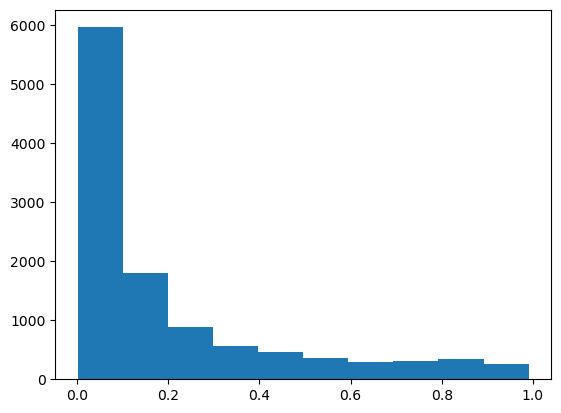

In [80]:
import matplotlib.pyplot as plt
plt.hist(train_probs[:,1])

In [81]:
(train_probs[:,1][:20]>0.2).astype(int)

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 1, 1, 0, 1])

In [82]:
(train_probs[:,1][:20]>0.5).astype(int)

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0])

In [83]:
train_probs[:,1].round(2)[:20]

array([0.13, 0.02, 0.03, 0.02, 0.09, 0.02, 0.06, 0.08, 0.02, 0.83, 0.16,
       0.  , 0.06, 0.84, 0.03, 0.97, 0.46, 0.36, 0.04, 0.23])

In [84]:
train_targets.value_counts(normalize=True)

Exited
0.0    0.798578
1.0    0.201422
Name: proportion, dtype: float64

In [85]:
model.classes_

array([0., 1.])

In [86]:
from sklearn.metrics import accuracy_score

In [87]:
accuracy_score(train_targets, train_preds)

0.8722666666666666

In [88]:
from sklearn.metrics import confusion_matrix

In [89]:
confusion_matrix(train_targets, train_preds)

array([[8622,  362],
       [1075, 1191]])

In [90]:
import seaborn as sns

def predict_and_plot(inputs, targets, name=''):
    preds = model.predict(inputs)

    accuracy = accuracy_score(targets, preds)
    print("Accuracy: {:.2f}%".format(accuracy * 100))

    cf = confusion_matrix(targets, preds, normalize='true')
    plt.figure()
    sns.heatmap(cf, annot=True)
    plt.xlabel('Prediction')
    plt.ylabel('Target')
    plt.title('{} Confusion Matrix'.format(name));

    return preds

Accuracy: 87.23%


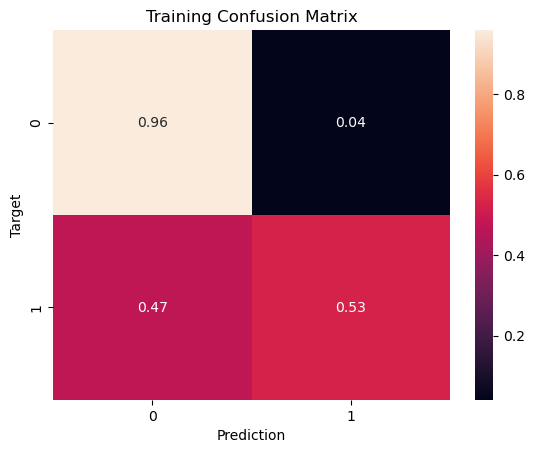

In [91]:
train_preds = predict_and_plot(X_train, train_targets, 'Training')

Accuracy: 87.07%


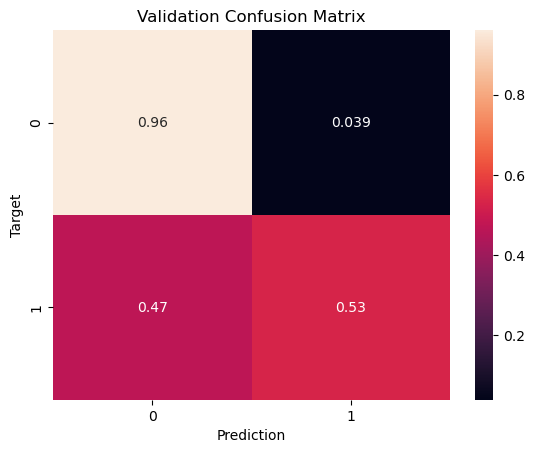

In [92]:
val_preds = predict_and_plot(X_val, val_targets, 'Validation')

In [95]:
from sklearn.metrics import f1_score

In [96]:
preds = model.predict(X_train)
preds[:5], train_targets[:5]

(array([0., 0., 0., 0., 0.]),
 7410     0.0
 10894    0.0
 1934     0.0
 11539    0.0
 2952     0.0
 Name: Exited, dtype: float64)

In [99]:
f1_score(train_targets, preds, pos_label=1)

0.6237234878240377

In [101]:
def get_f1_score(inputs, targets, name=''):
  preds = model.predict(inputs)

  f1_score_ = f1_score(targets, preds, pos_label=1)
  print(f"F1 score {name}: {f1_score_:.2f}%")

get_f1_score(X_train, train_targets, 'Training')
get_f1_score(X_val, val_targets, 'Validation')

F1 score Training: 0.62%
F1 score Validation: 0.63%


In [104]:
from sklearn.metrics import roc_curve, auc

def compute_auroc_and_build_roc(inputs, targets, name=''):
  # Predict probabilities
  y_pred_proba = model.predict_proba(inputs)[:, 1]

  # Compute ROC curve
  fpr, tpr, thresholds = roc_curve(targets, y_pred_proba, pos_label=1)

    # Compute AUROC
  roc_auc = auc(fpr, tpr)
  print(f'AUROC for {name}: {roc_auc:.2f}')

  # Plot the ROC curve
  plt.figure()
  plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
  plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
  plt.xlim([0.0, 1.0])
  plt.ylim([0.0, 1.05])
  plt.xlabel('False Positive Rate')
  plt.ylabel('True Positive Rate')
  plt.title(f'Receiver Operating Characteristic (ROC) Curve for {name}')
  plt.legend(loc="lower right")
  plt.show()

AUROC for Training: 0.88


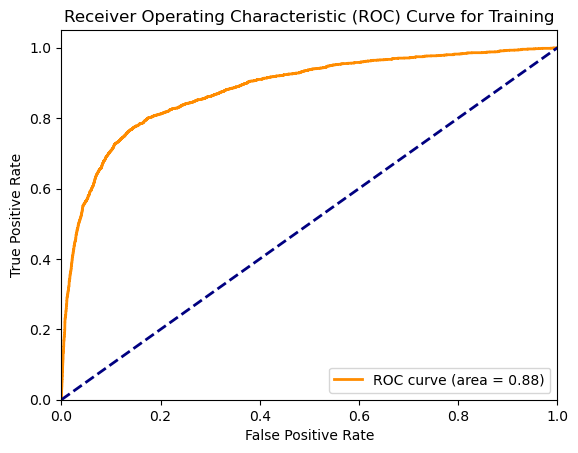

AUROC for Validation: 0.88


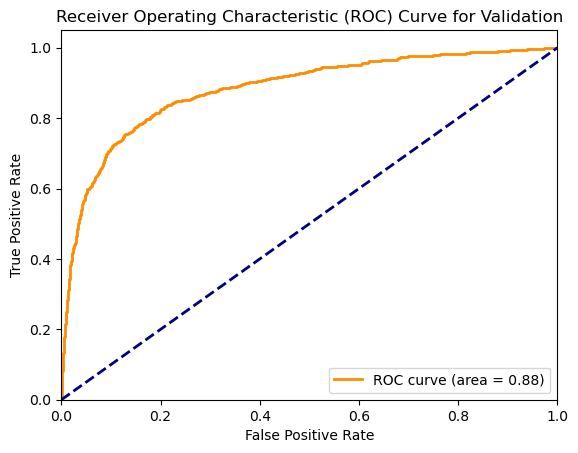

In [105]:
compute_auroc_and_build_roc(X_train, train_targets, 'Training')
compute_auroc_and_build_roc(X_val, val_targets, 'Validation')

In [106]:
test_probs = model.predict_proba(X_test)[:, 1]

In [107]:
submission = pd.DataFrame({
    'id': test_data['id'],
    'Exited': test_probs
})

In [108]:
submission.head()

,id,Exited
0,15000,0.073968
1,15001,0.032446
2,15002,0.157767
3,15003,0.189574
4,15004,0.051021


In [109]:
submission.to_csv(
    'submission.csv',
    index=False
)